## Megaline Business Review

Project Overview:
Telecom giant Megaline has hired an analyst. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

Preliminary analysis of the plans based on a relatively small client selection. Data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Following is analyzation of the clients' behavior and determine which prepaid plan brings in more revenue.

Sprint 3 covers Stastical Data Analysis (SDA)

Completion of this project will demonstrate ability to load, cleanse, and analyze data.  Project will revolve around evaluating 500 clinets of telecom operator Megaline.  They have two charge options of Surf or Ultimate.  

Surf
Monthly charge: $20
500 monthly minutes, 50 texts, and 15 GB of data
After exceeding the package limits:
1 minute: 3 cents
1 text message: 3 cents
1 GB of data: $10

Ultimate
Monthly charge: $70
3000 monthly minutes, 1000 text messages, and 30 GB of data
After exceeding the package limits:
1 minute: 1 cent
1 text message: 1 cent
1 GB of data: $7


The information to evaluate are contained from five different files which are uploaded to their own dataframes.

The data on users is stored in the "users" dataframe contains columns user_id  (unique user identifier), first_name  (user's name), last_name (user's last name), age (user's age in years), reg_date (subscription date following dd, mm, yy pattern), churn_date (the date the user stopped using the service (if the value is missing, the calling plan was being used when this database was extracted)), city (user's city of residence), and plan  (calling plan name). 

The "calls" data frame contains the data on calls.  The following columns exist:
id — unique call identifier
call_date — call date
duration — call duration (in minutes)
user_id — the identifier of the user making the call

The messages dataframe contains the data on texts.  The following columns exist:
id — unique text message identifier
message_date — text message date
user_id — the identifier of the user sending the text

The internet dataframe contains data on web sessions.  The following columns exist:
id — unique session identifier
mb_used — the volume of data spent during the session (in megabytes)
session_date — web session date
user_id — user identifier

The plans dataframe contains data on the plans.  The following columns exist:
plan_name — calling plan name
usd_monthly_fee — monthly charge in US dollars
minutes_included — monthly minute allowance
messages_included — monthly text allowance
mb_per_month_included — data volume allowance (in megabytes)
usd_per_minute — price per minute after exceeding the package limits (e.g., if the package includes 100 minutes, the 101st minute will be charged)
usd_per_message — price per text after exceeding the package limits
usd_per_gb — price per extra gigabyte of data after exceeding the package limits (1 GB = 1024 megabytes)



## Initialization

In [1]:
# Loading all the libraries 
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats as st



## Load data

In [2]:
# Load the data files into different DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet= pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


## Prepare the data

Each file type will be checked for duplicated rows and duplicates in columns (where necessary). Duplicates will be removed if found.  Each file will then be reviewed for missing values 

In [3]:
#Prepare data from "calls" file
print(calls.duplicated().sum())
#only 2 of the 4 columns matter if they are duplicated.  A call date and duraction can occur for multiple
#users.  However each call should be unique and each user_id should be unique 
print(calls.duplicated('id').sum())
print(calls.duplicated('user_id').sum())

calls.info()

0
0
137254
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [4]:
#check for empty cells in whole row
calls.isna().sum()
#check for empty cells in each column 
#calls['user_id'].isna().sum()
#calls['id'].isna().sum()
#calls['call_date'].isna().sum()
#calls['duration'].isna().sum()

#there are no empties so data clean for use 

id           0
user_id      0
call_date    0
duration     0
dtype: int64

In [5]:
#Prepare data from "users" file
print(users.duplicated().sum())
#only 1 of the 8 columns matter if they are duplicated. Each user should be unique and each user_id should be unique 
print(calls.duplicated('id').sum())

#gather general info
users.info()


0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [6]:
#check for empty cells in whole row
users.isna().sum()


user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

In [7]:
#churn_date has 466 empty which indicates that they are still current users so replace with NA 
users['churn_date']=users['churn_date'].fillna(pd.to_datetime('today'))
users.isna().sum()

user_id       0
first_name    0
last_name     0
age           0
city          0
reg_date      0
plan          0
churn_date    0
dtype: int64

In [8]:
#Prepare data from "internet" file
print(internet.duplicated().sum())
#none of the columns require unique values so no individual search 

#find general information rearding dataframe
calls.info()
#check for empty cells in whole row
internet.isna().sum()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

In [9]:
#Prepare data from "messages" file
print(messages.duplicated().sum())
#none of the columns require unique values so no individual search 

#find general information rearding dataframe
messages.info()
#check for empty cells in whole row
messages.isna().sum()


0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


id              0
user_id         0
message_date    0
dtype: int64

In [10]:
#Prepare data from "plans" file
print(plans.duplicated().sum())
#none of the columns require unique values so no individual search 

#find general information rearding dataframe
plans.info()
#check for empty cells in whole row
plans.isna().sum()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

## Plans

In [11]:
# Print the general/summary information about the plans' DataFrame
plans.describe()
plans.isnull().sum()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [12]:
# Print a sample of data for plans
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In the plans dataframe printout it is intersting that there are only two rows(one of each plan). There are three different data types (float, int64, and object).  There is no missing data. Noticing that the project instructions give the quanitty of information in GB.  However in the table they are listed as MB (with a correct conversion of 1 GB= 1024 MB).    

## Fix data

## Enrich data

In [13]:
plans['gb_per_month']=['15','30']
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month
0,50,15360,500,20,10,0.03,0.03,surf,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30


## Users

In [14]:
# Print the general/summary information about the users' DataFrame
users.describe()
users.isnull().sum()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [15]:
# Print a sample of data for users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,2025-04-18 16:45:03.204923
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,2025-04-18 16:45:03.204923
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,2025-04-18 16:45:03.204923
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,2025-04-18 16:45:03.204923
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,2025-04-18 16:45:03.204923


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

There are two different data types (object and int64). Previously discovered that there were missing null values in the churn_date column but replaced them with NA. 

### Fix Data

none are needed 

### Enrich Data

none are needed 

## Calls

In [16]:
# Print the general/summary information about the calls' DataFrame
calls.describe()
calls.isnull().sum()
calls.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [17]:
# Print a sample of data for calls
calls.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


The calls dataframe has object, float, and int64 datatypes.  There are no empty cells.  There is nothing needing further investigation. 

### Fix data

In [18]:
#convert data type of date column
calls['call_date']=pd.to_datetime(calls['call_date'])
calls.info()
print(calls.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27      8.52
1  1000_145     1000 2018-12-27     13.66
2  1000_247     1000 2018-12-27     14.48
3  1000_309     1000 2018-12-28      5.76
4  1000_380     1000 2018-12-30      4.22


### Enrich data

In [19]:
calls['duration']=calls['duration'].apply(np.ceil).astype(int)

## Messages

In [20]:
# Print the general/summary information about the messages' DataFrame
messages.describe()
messages.isnull().sum()
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [21]:
# Print a sample of data for messages
messages.tail()


,id,user_id,message_date
76046,1497_526,1497,2018-12-24
76047,1497_536,1497,2018-12-24
76048,1497_547,1497,2018-12-31
76049,1497_558,1497,2018-12-24
76050,1497_613,1497,2018-12-23


Messages dataframe has object and integer data types.  There are no empty cells or rows.  No further investigation needed. 

### Fix data

In [22]:
#convert date datatype
messages['message_date']=pd.to_datetime(messages['message_date'])
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enrich data

none

## Internet

In [23]:
# Print the general/summary information about the internet DataFrame
internet.describe()
internet.isnull().sum()
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [24]:
# Print a sample of data for the internet traffic
internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


The internet dataframe contains floats, integers, and objects.  There are no missing data rows or columns.  

### Fix data

In [25]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enrich data

none needed 

## Study plan conditions

# Print out the plan conditions and make sure they are clear for you
Surf
Monthly charge: $20
500 monthly minutes, 50 texts, and 15 GB of data
After exceeding the package limits:
1 minute: 3 cents
1 text message: 3 cents
1 GB of data: $10

Ultimate
Monthly charge: $70
3000 monthly minutes, 1000 text messages, and 30 GB of data
After exceeding the package limits:
1 minute: 1 cent
1 text message: 1 cent
1 GB of data: $7


In [26]:
plans.columns
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month
0,50,15360,500,20,10,0.03,0.03,surf,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30


## Aggregate data per user

[Aggregate data per user per period in order to have just one record per user per period to ease the further analysis a lot.]

In [27]:
# Calculate the number of calls made by each user per month. Save the result.
# Calculate the amount of minutes spent by each user per month. Save the result.
calls['month']=calls['call_date'].dt.month
calls_per_user=calls.groupby(['user_id','month']).agg({'call_date':'count', 'duration': 'sum'})
calls_per_user

call_date  duration
user_id month                     
1000    12            16       124
1001    8             27       182
        9             49       315
        10            65       393
        11            64       426
...                  ...       ...
1498    12            39       339
1499    9             41       346
        10            53       385
        11            45       308
        12            65       496

[2258 rows x 2 columns]

In [28]:
# Calculate the number of messages sent by each user per month. Save the result.
#convert time listing into a month listing
messages['month']=messages['message_date'].dt.month
message_per_user=messages.groupby(['user_id','month']).agg({'message_date':'count'})
message_per_user


message_date
user_id month              
1000    12               11
1001    8                30
        9                44
        10               53
        11               36
...                     ...
1496    9                21
        10               18
        11               13
        12               11
1497    12               50

[1806 rows x 1 columns]

In [29]:
# Calculate the volume of internet traffic used by each user per month. Save the result.
#convert time listing into a month listing
internet['month']=internet['session_date'].dt.month
traffic_volume=internet.groupby(['user_id','month']).agg({'mb_used':'sum'})
traffic_volume

mb_used
user_id month          
1000    12      1901.47
1001    8       6919.15
        9      13314.82
        10     22330.49
        11     18504.30
...                 ...
1498    12     23137.69
1499    9      12984.76
        10     19492.43
        11     16813.83
        12     22059.21

[2277 rows x 1 columns]

[Put the aggregate data together into one DataFrame so that one record in it would represent what an unique user consumed in a given month.]

In [30]:
# Merge the data for calls, minutes, messages, internet based on user_id and month
#double check with another method 
user_monthly_info=pd.concat([calls_per_user, message_per_user, traffic_volume], axis=1,)
user_monthly_info=user_monthly_info.fillna(0)
user_monthly_info.reset_index(inplace=True)
user_monthly_info.head()


,user_id,month,call_date,duration,message_date,mb_used
0,1000,12,16.0,124.0,11.0,1901.47
1,1001,8,27.0,182.0,30.0,6919.15
2,1001,9,49.0,315.0,44.0,13314.82
3,1001,10,65.0,393.0,53.0,22330.49
4,1001,11,64.0,426.0,36.0,18504.30


In [31]:
#add which type of plan users had 
user_monthly_info = user_monthly_info.merge(users, on=['user_id'], how='inner')
user_monthly_info


,user_id,month,call_date,duration,message_date,mb_used,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,12,16.0,124.0,11.0,1901.47,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,2025-04-18 16:45:03.204923
1,1001,8,27.0,182.0,30.0,6919.15,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,2025-04-18 16:45:03.204923
2,1001,9,49.0,315.0,44.0,13314.82,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,2025-04-18 16:45:03.204923
3,1001,10,65.0,393.0,53.0,22330.49,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,2025-04-18 16:45:03.204923
4,1001,11,64.0,426.0,36.0,18504.30,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,2025-04-18 16:45:03.204923
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,12,39.0,339.0,0.0,23137.69,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,2025-04-18 16:45:03.204923
2289,1499,9,41.0,346.0,0.0,12984.76,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,2025-04-18 16:45:03.204923
2290,1499,10,53.0,385.0,0.0,19492.43,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,2025-04-18 16:45:03.204923
2291,1499,11,45.0,308.0,0.0,16813.83,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,2025-04-18 16:45:03.204923


In [32]:
# Add the plan information
#ensure columns match.  The common column is "plans" and "plan_name"
plans.columns
user_monthly_info.columns
user_monthly_info_cleaned = user_monthly_info.loc[:, ~user_monthly_info.columns.duplicated()]
monthly_info = user_monthly_info_cleaned.merge(plans, left_on='plan', right_on='plan_name', how='left')
monthly_info

,user_id,month,call_date,duration,message_date,mb_used,first_name,last_name,age,city,...,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month
0,1000,12,16.0,124.0,11.0,1901.47,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",...,2025-04-18 16:45:03.204923,1000,30720,3000,70,7,0.01,0.01,ultimate,30
1,1001,8,27.0,182.0,30.0,6919.15,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
2,1001,9,49.0,315.0,44.0,13314.82,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
3,1001,10,65.0,393.0,53.0,22330.49,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
4,1001,11,64.0,426.0,36.0,18504.30,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,12,39.0,339.0,0.0,23137.69,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
2289,1499,9,41.0,346.0,0.0,12984.76,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
2290,1499,10,53.0,385.0,0.0,19492.43,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15
2291,1499,11,45.0,308.0,0.0,16813.83,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",...,2025-04-18 16:45:03.204923,50,15360,500,20,10,0.03,0.03,surf,15


[Calculate the monthly revenue from each user (subtract the free package limit from the total number of calls, text messages, and data; multiply the result by the calling plan value; add the monthly charge depending on the calling plan).

In [33]:
monthly_info.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   call_date              2293 non-null   float64
 3   duration               2293 non-null   float64
 4   message_date           2293 non-null   float64
 5   mb_used                2293 non-null   float64
 6   first_name             2293 non-null   object 
 7   last_name              2293 non-null   object 
 8   age                    2293 non-null   int64  
 9   city                   2293 non-null   object 
 10  reg_date               2293 non-null   object 
 11  plan                   2293 non-null   object 
 12  churn_date             2293 non-null   object 
 13  messages_included      2293 non-null   int64  
 14  mb_per_month_included  2293 non-null   int64  
 15  minu

In [34]:
# Calculate the monthly revenue for each user
#first calculate the overage cost for each user in messages, minute, and gb overages
monthly_info['message_cost']=((monthly_info['message_date']-monthly_info['messages_included']).clip(lower=0))*monthly_info['usd_per_message']
monthly_info['minute_cost']=((monthly_info['duration']-monthly_info['minutes_included']).clip(lower=0))*monthly_info['usd_per_minute']

#convert to be same datatype.  needs to be float to perform calculations
monthly_info['mb_per_month_included']= monthly_info['mb_per_month_included'].astype(float)
monthly_info['gb_per_month']= monthly_info['gb_per_month'].astype(float)

monthly_info['extra_gb']=(monthly_info['mb_used']-monthly_info['mb_per_month_included']).clip(lower=0)
monthly_info['monthly_gb_cost']=np.ceil(monthly_info['extra_gb']/1024)*monthly_info['usd_per_gb']
#monthly_info['gb_cost']=(np.ceil(monthly_info['mb_used']-monthly_info['mb_per_month_included']).clip(lower=0)/1024)*monthly_info['usd_per_gb']

#total monthly cost will be the plan cost+monthly minute overage+gb overage+message overage
monthly_info['monthly_revenue']=monthly_info['usd_monthly_pay']+monthly_info['minute_cost']+monthly_info['monthly_gb_cost']+monthly_info['message_cost']
monthly_info

,user_id,month,call_date,duration,message_date,mb_used,first_name,last_name,age,city,...,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month,message_cost,minute_cost,extra_gb,monthly_gb_cost,monthly_revenue
0,1000,12,16.0,124.0,11.0,1901.47,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",...,7,0.01,0.01,ultimate,30.0,0.00,0.0,0.00,0.0,70.00
1,1001,8,27.0,182.0,30.0,6919.15,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,0.00,0.0,20.00
2,1001,9,49.0,315.0,44.0,13314.82,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,0.00,0.0,20.00
3,1001,10,65.0,393.0,53.0,22330.49,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,10,0.03,0.03,surf,15.0,0.09,0.0,6970.49,70.0,90.09
4,1001,11,64.0,426.0,36.0,18504.30,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,3144.30,40.0,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,12,39.0,339.0,0.0,23137.69,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,7777.69,80.0,100.00
2289,1499,9,41.0,346.0,0.0,12984.76,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,0.00,0.0,20.00
2290,1499,10,53.0,385.0,0.0,19492.43,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,4132.43,50.0,70.00
2291,1499,11,45.0,308.0,0.0,16813.83,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",...,10,0.03,0.03,surf,15.0,0.00,0.0,1453.83,20.0,40.00


## Study user behaviour

Calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. 

### Calls

        plan  month    duration
0       surf      1  203.000000
1       surf      2  297.000000
2       surf      3  330.000000
3       surf      4  351.540000
4       surf      5  399.584416
5       surf      6  431.298969
6       surf      7  449.983471
7       surf      8  410.111111
8       surf      9  414.226804
9       surf     10  429.729958
10      surf     11  423.325088
11      surf     12  473.836478
12  ultimate      1  193.500000
13  ultimate      2  403.142857
14  ultimate      3  304.250000
15  ultimate      4  336.857143
16  ultimate      5  406.241379
17  ultimate      6  370.957447
18  ultimate      7  427.067797
19  ultimate      8  421.436620
20  ultimate      9  437.511628
21  ultimate     10  450.735849
22  ultimate     11  445.196850
23  ultimate     12  459.099338


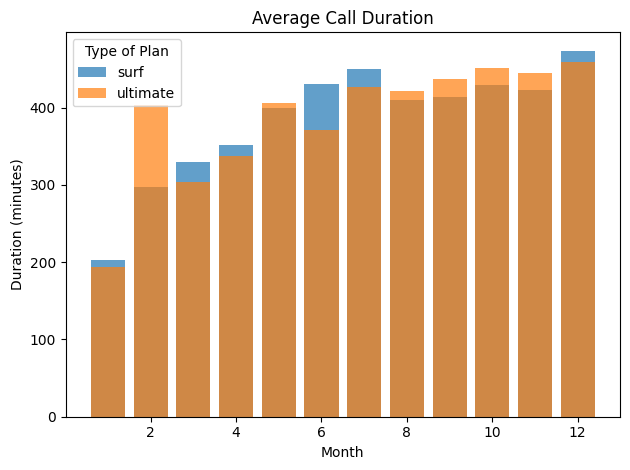

In [35]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plat to visualize it.
#create table of information just with plan, month, and duration sum
average_duration=monthly_info.groupby(['plan','month']).agg({'duration':'mean'}).reset_index()
print(average_duration)


for plan in average_duration['plan'].unique():
    subset = average_duration[average_duration['plan'] == plan]
    plt.bar(subset['month'], subset['duration'], label=plan, alpha=0.7)

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Duration (minutes)')
plt.title('Average Call Duration')
plt.legend(title='Type of Plan')
plt.tight_layout()



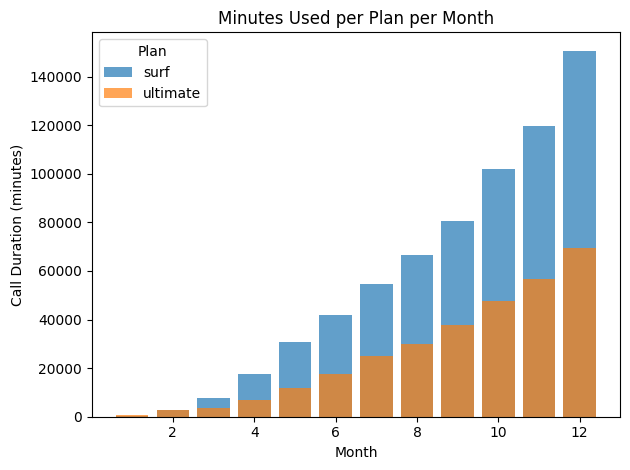

In [36]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.
plan_minutes = monthly_info.groupby(['plan', 'month'])['duration'].sum().reset_index()

# Plotting
plt.figure()

# Plot each plan
for plan in plan_minutes['plan'].unique():
    subset = plan_minutes[plan_minutes['plan'] == plan]
    plt.bar(subset['month'], subset['duration'], label=plan, alpha=0.7)

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Call Duration (minutes)')
plt.title('Minutes Used per Plan per Month')
plt.legend(title='Plan')
plt.tight_layout()


In [37]:
# Calculate the mean and the variance of the monthly call duration
monthly_call_stats= monthly_info.groupby(['plan', 'month'])['duration'].agg(['mean', 'var']).reset_index()
print(monthly_call_stats)

        plan  month        mean           var
0       surf      1  203.000000  15842.000000
1       surf      2  297.000000  52226.500000
2       surf      3  330.000000  35809.363636
3       surf      4  351.540000  50866.743265
4       surf      5  399.584416  59754.219754
5       surf      6  431.298969  45592.628436
6       surf      7  449.983471  61005.099725
7       surf      8  410.111111  54344.645963
8       surf      9  414.226804  46595.958656
9       surf     10  429.729958  52278.664056
10      surf     11  423.325088  51607.021602
11      surf     12  473.836478  63629.518918
12  ultimate      1  193.500000  16572.333333
13  ultimate      2  403.142857  76889.476190
14  ultimate      3  304.250000  61984.931818
15  ultimate      4  336.857143  34888.928571
16  ultimate      5  406.241379  43841.046798
17  ultimate      6  370.957447  42503.563367
18  ultimate      7  427.067797  72563.374635
19  ultimate      8  421.436620  53645.506640
20  ultimate      9  437.511628  5

In [38]:
surf = monthly_call_stats[monthly_call_stats['plan'] == 'surf']
ultimate = monthly_call_stats[monthly_call_stats['plan'] == 'ultimate']
print(surf.head())
print(ultimate.head())

   plan  month        mean           var
0  surf      1  203.000000  15842.000000
1  surf      2  297.000000  52226.500000
2  surf      3  330.000000  35809.363636
3  surf      4  351.540000  50866.743265
4  surf      5  399.584416  59754.219754
        plan  month        mean           var
12  ultimate      1  193.500000  16572.333333
13  ultimate      2  403.142857  76889.476190
14  ultimate      3  304.250000  61984.931818
15  ultimate      4  336.857143  34888.928571
16  ultimate      5  406.241379  43841.046798


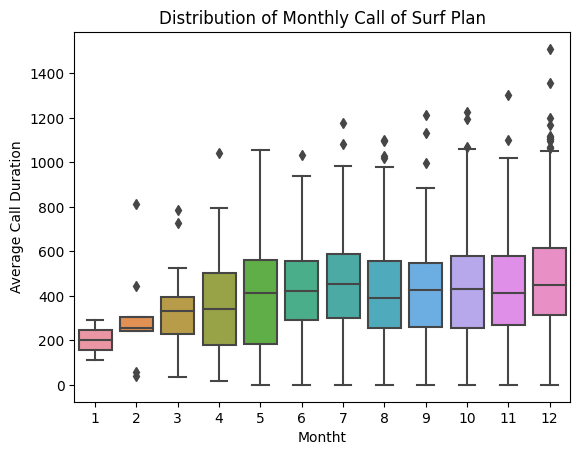

In [39]:
#create df of each type of plan
surf = monthly_info[monthly_info['plan'] == 'surf']
ultimate = monthly_info[monthly_info['plan'] == 'ultimate']

# Plot a boxplot to visualize the distribution of the monthly call duration
sns.boxplot(data=surf, x='month', y='duration')

plt.title('Distribution of Monthly Call of Surf Plan')
plt.xlabel('Montht')
plt.ylabel('Average Call Duration')
plt.show()




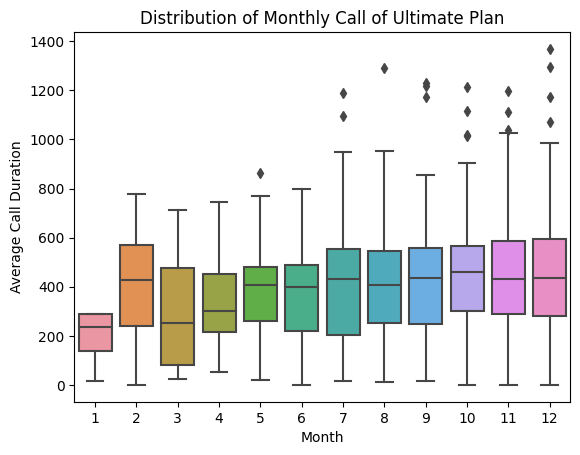

In [40]:
#create new boxplot 
sns.boxplot(data=ultimate, x='month', y='duration')

#fig, ax = plt.subplots()
plt.title('Distribution of Monthly Call of Ultimate Plan')
plt.xlabel('Month')
plt.ylabel('Average Call Duration')
plt.show()

Overallthe surf plan users make more calls during the year.  The calls tend to increase as the year goes on regardless of plan type chosen. 

### Messages

In [41]:
# Compare the number of messages users of each plan tend to send each month
average_messages = monthly_info.groupby(['plan', 'month'])['message_date'].sum().reset_index()
print(average_messages)


        plan  month  message_date
0       surf      1          21.0
1       surf      2         108.0
2       surf      3         351.0
3       surf      4         870.0
4       surf      5        1849.0
5       surf      6        2454.0
6       surf      7        3271.0
7       surf      8        4662.0
8       surf      9        5968.0
9       surf     10        8020.0
10      surf     11        9165.0
11      surf     12       12275.0
12  ultimate      1          62.0
13  ultimate      2         151.0
14  ultimate      3         243.0
15  ultimate      4         463.0
16  ultimate      5         931.0
17  ultimate      6        1379.0
18  ultimate      7        1937.0
19  ultimate      8        2732.0
20  ultimate      9        3259.0
21  ultimate     10        4181.0
22  ultimate     11        4903.0
23  ultimate     12        6796.0


        plan  month      gb_used
0       surf      1     9.521211
1       surf      2   107.040615
2       surf      3   299.751094
3       surf      4   585.166162
4       surf      5  1047.948564
5       surf      6  1449.461260
6       surf      7  1983.218428
7       surf      8  2657.073906
8       surf      9  3143.298506
9       surf     10  4006.627354
10      surf     11  4515.633789
11      surf     12  5630.981699
12  ultimate      1    27.023799
13  ultimate      2   117.091465
14  ultimate      3   214.705293
15  ultimate      4   330.619873
16  ultimate      5   470.810537
17  ultimate      6   703.986611
18  ultimate      7   941.738203
19  ultimate      8  1235.200322
20  ultimate      9  1425.203887
21  ultimate     10  1823.174473
22  ultimate     11  2112.576211
23  ultimate     12  2701.955049


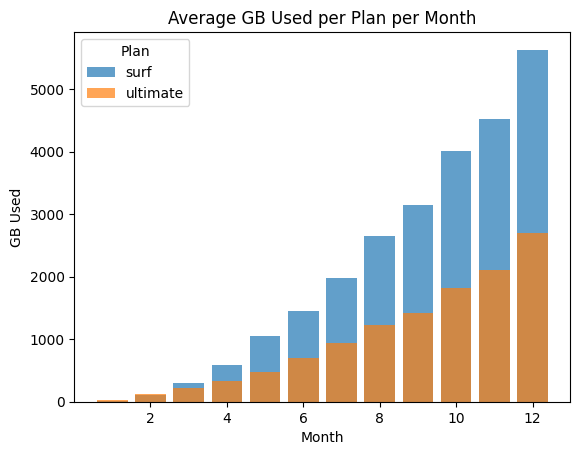

In [42]:
# Compare the amount of internet traffic consumed by users per plan
monthly_info['gb_used']=monthly_info['mb_used']/1024
average_gb_usage = monthly_info.groupby(['plan', 'month'])['gb_used'].sum().reset_index()
print(average_gb_usage)
# Plotting
plt.figure()

# Plot each plan
for plan in average_gb_usage['plan'].unique():
    subset = average_gb_usage[average_gb_usage['plan'] == plan]
    plt.bar(subset['month'], subset['gb_used'], label=plan, alpha=0.7)

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('GB Used')
plt.title('Average GB Used per Plan per Month')
plt.legend(title='Plan')


The surf plan uses more GB overall.  In January neither plan is using more than 1000 GB.  However by December surf plan customers are above 5000 GB and ultimate plan as close to 3000 GB.  In the month of December almost 2x usage of GB compared to Ultimate plan.  The usage seems closer in the beginning of the year. 

### Internet

Internet traffic increases as the months progress.  Stating in March the number of gB used in surf plan is double than ultimate plan. 

## Revenue

        plan  month  monthly_revenue
0       surf      1            40.00
1       surf      2           309.57
2       surf      3          1056.65
3       surf      4          2035.53
4       surf      5          3667.37
5       surf      6          4779.80
6       surf      7          7583.56
7       surf      8         10356.85
8       surf      9         11304.67
9       surf     10         15504.83
10      surf     11         16415.21
11      surf     12         22437.14
12  ultimate      1           280.00
13  ultimate      2           490.00
14  ultimate      3           896.00
15  ultimate      4          1533.00
16  ultimate      5          2051.00
17  ultimate      6          3367.00
18  ultimate      7          4242.00
19  ultimate      8          5173.00
20  ultimate      9          6195.00
21  ultimate     10          7665.00
22  ultimate     11          9107.00
23  ultimate     12         11067.00


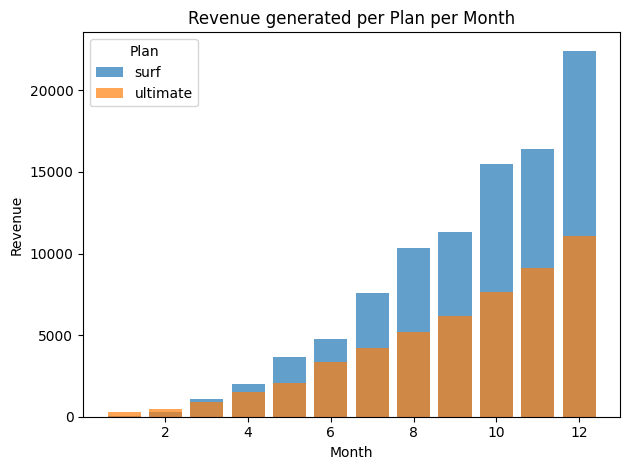

In [43]:
# Compare the revenue of each type of plan generate. Plot a histogram.
plan_revenue = monthly_info.groupby(['plan', 'month'])['monthly_revenue'].sum().reset_index()
print(plan_revenue)
# Plotting
plt.figure()

# Plot each plan
for plan in plan_revenue['plan'].unique():
    subset = plan_revenue[plan_revenue['plan'] == plan]
    plt.bar(subset['month'], subset['monthly_revenue'], label=plan, alpha=0.7)

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Revenue generated per Plan per Month')
plt.legend(title='Plan')
plt.tight_layout()

In [44]:
#evaluate which plan goes over their plan more 
#create a column for messages, minutes, and gb determining overages 
#calculate message overages 
monthly_info['monthly_message_usage']=(monthly_info['message_date']-monthly_info['messages_included']).clip(lower=0)
#group by plan and print to confirm that done correctly 
over_messages = monthly_info.groupby(['plan', 'month'])['monthly_message_usage'].sum().reset_index()
print(over_messages)



        plan  month  monthly_message_usage
0       surf      1                    0.0
1       surf      2                    8.0
2       surf      3                   13.0
3       surf      4                   87.0
4       surf      5                  322.0
5       surf      6                  483.0
6       surf      7                  586.0
7       surf      8                  973.0
8       surf      9                 1203.0
9       surf     10                 1986.0
10      surf     11                 1988.0
11      surf     12                 3382.0
12  ultimate      1                    0.0
13  ultimate      2                    0.0
14  ultimate      3                    0.0
15  ultimate      4                    0.0
16  ultimate      5                    0.0
17  ultimate      6                    0.0
18  ultimate      7                    0.0
19  ultimate      8                    0.0
20  ultimate      9                    0.0
21  ultimate     10                    0.0
22  ultimat

In [45]:
#calculate minute overages and print some to confirm
monthly_info['monthly_minute_usage']=(monthly_info['duration']-monthly_info['minutes_included']).clip(lower=0)
over_minutes = monthly_info.groupby(['plan', 'month'])['monthly_message_usage'].sum().reset_index()
print(over_minutes.head())

   plan  month  monthly_message_usage
0  surf      1                    0.0
1  surf      2                    8.0
2  surf      3                   13.0
3  surf      4                   87.0
4  surf      5                  322.0


In [46]:
#calculate internet overages and print some to confirm
monthly_info['over_internet']=(monthly_info['mb_used']-monthly_info['gb_per_month']).clip(lower=0)
over_internet = monthly_info.groupby(['plan', 'month'])['extra_gb'].sum().reset_index()
print(over_internet.head())


   plan  month   extra_gb
0  surf      1       0.00
1  surf      2   11133.44
2  surf      3   54183.54
3  surf      4   91764.66
4  surf      5  188884.11


In [47]:
#merge together the individual overage dataframes for messages, minutes, and internet
monthly_overage=pd.concat([over_minutes, over_messages, over_internet], axis=1,)
#fill in any blank spaces with zero
monthly_overage=monthly_overage.fillna(0)
monthly_overage.reset_index(inplace=True)
monthly_overage.head()


,index,plan,month,monthly_message_usage,plan,month,monthly_message_usage,plan,month,extra_gb
0,0,surf,1,0.0,surf,1,0.0,surf,1,0.00
1,1,surf,2,8.0,surf,2,8.0,surf,2,11133.44
2,2,surf,3,13.0,surf,3,13.0,surf,3,54183.54
3,3,surf,4,87.0,surf,4,87.0,surf,4,91764.66
4,4,surf,5,322.0,surf,5,322.0,surf,5,188884.11


Ultimate users tend do not surpass their minute or message usage.  However they do sometimes surpass their gB allowances.  Surf users routinely surpass in minutes, messages, and gB (except not in January).  

## Test statistical hypotheses

In [48]:
# Test the hypotheses
#H0 hypothesis is that there is no difference between the average revenue from users of the Ultimate and Surf calling plans differ 
#H1 hypothesis is that there is a difference between the average revenue from users of the Ultimate and Surf calling plans differ 

# set the critical statistical significance level at statistical acceptance
alpha = 0.05

#updated problem for using columns rather than hardcoded values. 
surf_revenue_test = plan_revenue[plan_revenue['plan'] == 'surf']
print(surf_revenue_test)
ultimate_revenue_test = plan_revenue[plan_revenue['plan'] == 'ultimate']
print(ultimate_revenue_test)
results = st.ttest_ind(surf_revenue_test['monthly_revenue'], ultimate_revenue_test['monthly_revenue'])
# test the hypothesis that the means of the two independent populations are equal

print('p-value:', results.pvalue) # your code: print the p-value you get

if results.pvalue<alpha:# your code: compare the p-value you get with the significance level):
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")


    plan  month  monthly_revenue
0   surf      1            40.00
1   surf      2           309.57
2   surf      3          1056.65
3   surf      4          2035.53
4   surf      5          3667.37
5   surf      6          4779.80
6   surf      7          7583.56
7   surf      8         10356.85
8   surf      9         11304.67
9   surf     10         15504.83
10  surf     11         16415.21
11  surf     12         22437.14
        plan  month  monthly_revenue
12  ultimate      1            280.0
13  ultimate      2            490.0
14  ultimate      3            896.0
15  ultimate      4           1533.0
16  ultimate      5           2051.0
17  ultimate      6           3367.0
18  ultimate      7           4242.0
19  ultimate      8           5173.0
20  ultimate      9           6195.0
21  ultimate     10           7665.0
22  ultimate     11           9107.0
23  ultimate     12          11067.0
p-value: 0.13760614119010917
We can't reject the null hypothesis


In [49]:
# Test the hypotheses
#H0= The average revenue from users in NY/NJ is the same as users from other area in the country. 
#H1=The average revenue from users in NY/NJ is different from other areas of the country. 
#create revenue data for NJ/NY
ny_nj_revenue = monthly_info[monthly_info['city'].str.contains('NY-NJ')]
ny_nj_revenue



,user_id,month,call_date,duration,message_date,mb_used,first_name,last_name,age,city,...,gb_per_month,message_cost,minute_cost,extra_gb,monthly_gb_cost,monthly_revenue,gb_used,monthly_message_usage,monthly_minute_usage,over_internet
56,1014,11,28.0,163.0,9.0,1175.59,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,0.00,0.0,20.00,1.148037,0.0,0.0,1160.59
57,1014,12,150.0,1114.0,64.0,7792.41,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.42,18.42,0.00,0.0,38.84,7.609775,14.0,614.0,7777.41
75,1022,5,39.0,302.0,0.0,4908.08,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,0.00,0.0,20.00,4.793047,0.0,0.0,4893.08
76,1022,6,76.0,490.0,0.0,23436.48,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,8076.48,80.0,100.00,22.887187,0.0,0.0,23421.48
77,1022,7,70.0,475.0,0.0,9933.15,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,0.00,0.0,20.00,9.700342,0.0,0.0,9918.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284,1498,8,44.0,266.0,0.0,20261.89,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,4901.89,50.0,70.00,19.787002,0.0,0.0,20246.89
2285,1498,9,45.0,363.0,0.0,22827.28,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,7467.28,80.0,100.00,22.292266,0.0,0.0,22812.28
2286,1498,10,46.0,298.0,0.0,20580.76,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,5220.76,60.0,80.00,20.098398,0.0,0.0,20565.76
2287,1498,11,41.0,223.0,0.0,19168.55,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,15.0,0.00,0.00,3808.55,40.0,60.00,18.719287,0.0,0.0,19153.55


In [50]:
# Extract revenue data for other regions
other_regions_revenue = monthly_info[~monthly_info['city'].str.contains('NY-NJ')]
print(other_regions_revenue.head(20))

    user_id  month  call_date  duration  message_date   mb_used first_name  \
0      1000     12       16.0     124.0          11.0   1901.47   Anamaria   
1      1001      8       27.0     182.0          30.0   6919.15     Mickey   
2      1001      9       49.0     315.0          44.0  13314.82     Mickey   
3      1001     10       65.0     393.0          53.0  22330.49     Mickey   
4      1001     11       64.0     426.0          36.0  18504.30     Mickey   
5      1001     12       56.0     412.0          44.0  19369.18     Mickey   
6      1002     10       11.0      59.0          15.0   6552.01     Carlee   
7      1002     11       55.0     386.0          32.0  19345.08     Carlee   
8      1002     12       47.0     384.0          41.0  14396.24     Carlee   
9      1003     12      149.0    1104.0          50.0  27044.14   Reynaldo   
10     1004      5       21.0     193.0           7.0   6547.21    Leonila   
11     1004      6       44.0     275.0          18.0  20672.82 

In [51]:
alpha = 0.05
# set the critical statistical significance level at statistical acceptance

results = st.ttest_ind(ny_nj_revenue['monthly_revenue'],other_regions_revenue['monthly_revenue'],equal_var=False)
# test the hypothesis that the means of the two independent populations are equal

print('p-value:', results.pvalue) # your code: print the p-value you get

if results.pvalue<alpha:# your code: compare the p-value you get with the significance level):
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value: 0.0335256158853001
We reject the null hypothesis


## General conclusion

Megaline has laid out interesting options for their clients.  Their is a tiered structure to choose for payment based on how many minutes talking, messages sent, and GB of internet used.  Each provided file was checked for duplicated rows and null values.  Wherever a date was missing for ‘churn_date” because users are still current customers todays date was inserted.  Through evaluations some of the datatypes of columns were required to be changed integer or formatting style.  The minutes columns for how long users talked needed to be rounded up if it was any decimal point.  Internet usage was provided in MB but we were concerned with GB so it was divided by 1024 to be reported in GB.  

Since users made multiple entries per month an aggregated dataframe was created with each user_id listing the phone usage per month.  Each time point was adjusted to reflect only the month the task was performed in.  The monthly revenue per user was calculated by subtracting the usage values from users plan allowance.  Any overages were multiplied by plan dictated surcharges. 

Ultimately the surf plan generates more revenue for Megaline.  The plan is less expensive but users tend to use over their allotted minutes, messages, and GB of data.  This issue increases towards the end of the year.  In order to generate more money perhaps Megaline should considering lowering the usage terms (less minutes, messages, and GB).  Statistically the average revenue does not differ and NY/NJ residents do not spend more.  All of this was learned through statistical data analysis.  
